In [1]:
import pandas as pd
import pathlib
from pathlib import Path
from glob import glob
import json
import os

In [2]:
def read_states_run(run_path: pathlib.PosixPath):
    properties_file = run_path / "static-properties"
    state_file = run_path / "state_data.csv"
    plan_file = run_path / "sas_plan"
    if not os.path.isfile(properties_file) or \
        not os.path.isfile(state_file):
        return pd.DataFrame()

    properties = None
    with open(properties_file) as file:
        properties = json.load(file)
    
    df = pd.read_csv(state_file)
    df['domain'] = properties['domain']
    df['problem'] = properties['problem']
    df['solved'] = os.path.isfile(plan_file)
    return df

def read_states_domain(exp_data: pathlib.PosixPath):
    search_glob = map(Path, glob(str(exp_data / "runs-*" / "*")))
    
    dfs = []
    for run_path in search_glob:
        dfs.append(read_states_run(run_path))
    return dfs

In [3]:
example =   read_states_domain(pathlib.Path('./data/2025-04-20-A-state_extraction'))[0]
example

,index,sequence,buff0,var0,var1,var2,var3,var4,var5,var6,var7,var8,var9,var10,var11,var12,var13,domain,problem,solved
0,-1,0,3,3,2,2,2,2,2,2,4,4,2,2,9,9,NaN,depot,p01.pddl,True
1,1,0,202855,0,2,1,1,0,0,0,0,1,0,0,0,7,6.0,depot,p01.pddl,True
2,2,0,203111,1,2,1,1,0,0,0,0,1,0,0,0,7,6.0,depot,p01.pddl,True
3,3,0,203367,2,2,1,1,0,0,0,0,1,0,0,0,7,6.0,depot,p01.pddl,True
4,4,0,200807,0,0,1,1,0,0,0,0,1,0,0,0,7,6.0,depot,p01.pddl,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,395,1,6601348,2,2,0,0,1,0,0,1,3,2,1,0,4,8.0,depot,p01.pddl,True
196,396,1,14219826,2,2,0,0,0,1,1,0,3,3,1,1,2,3.0,depot,p01.pddl,True
197,397,1,9553974,0,2,1,0,0,0,1,0,0,3,0,1,6,3.0,depot,p01.pddl,True
198,398,1,4880498,0,2,0,1,0,1,0,0,3,1,1,0,2,7.0,depot,p01.pddl,True


In [4]:
df = example.loc[1:, "var0":"var13"].copy(deep=True)
domain_sizes = example.loc[0, "var0":"var13"]
df, domain_size

NameError: name 'domain_size' is not defined

In [ ]:
import pandas as pd
import numpy as np
from IPython.display import display, Markdown

# Assume df and domain_sizes are defined

cols = df.columns
n = len(cols)
obs_ratio_matrix = pd.DataFrame(np.nan, index=cols, columns=cols)

for i in range(n):
    for j in range(n):
        if i == j:
            obs_ratio_matrix.iloc[i, j] = np.nan
            continue
        col_i, col_j = cols[i], cols[j]
        observed = df[[col_i, col_j]].drop_duplicates()
        actual_count = len(observed)
        possible_count = domain_sizes[col_i] * domain_sizes[col_j]
        ratio = actual_count / possible_count if possible_count > 0 else np.nan
        obs_ratio_matrix.iloc[i, j] = ratio

# Display the title and matrix in Jupyter
display(Markdown('## Ratio of Observed to Potential Value Pairs for Each Variable Pair'))
display(
    obs_ratio_matrix.style
        .format("{:.2%}")
        .background_gradient(cmap="YlGn")
)

## Ratio of Observed to Potential Value Pairs for Each Variable Pair

,var0,var1,var2,var3,var4,var5,var6,var7,var8,var9,var10,var11,var12,var13
var0,nan%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,88.89%,88.89%
var1,100.00%,nan%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,88.89%,88.89%
var2,100.00%,100.00%,nan%,100.00%,75.00%,100.00%,100.00%,100.00%,75.00%,62.50%,100.00%,100.00%,77.78%,66.67%
var3,100.00%,100.00%,100.00%,nan%,75.00%,100.00%,100.00%,100.00%,62.50%,75.00%,100.00%,100.00%,72.22%,77.78%
var4,100.00%,100.00%,75.00%,75.00%,nan%,100.00%,75.00%,100.00%,62.50%,62.50%,100.00%,100.00%,61.11%,66.67%
var5,100.00%,100.00%,100.00%,100.00%,100.00%,nan%,100.00%,100.00%,100.00%,87.50%,100.00%,100.00%,77.78%,77.78%
var6,100.00%,100.00%,100.00%,100.00%,75.00%,100.00%,nan%,100.00%,87.50%,87.50%,100.00%,100.00%,72.22%,72.22%
var7,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,nan%,87.50%,100.00%,100.00%,100.00%,72.22%,77.78%
var8,100.00%,100.00%,75.00%,62.50%,62.50%,100.00%,87.50%,87.50%,nan%,50.00%,50.00%,75.00%,22.22%,61.11%
var9,100.00%,100.00%,62.50%,75.00%,62.50%,87.50%,87.50%,100.00%,50.00%,nan%,75.00%,50.00%,61.11%,22.22%


In [ ]:
import pandas as pd
import numpy as np
from IPython.display import display, Markdown

# Assume df is your DataFrame of categorical variables

cols = df.columns
n = len(cols)

# Compute domain sizes as number of unique values in each column
domain_sizes = df.nunique()

obs_ratio_matrix = pd.DataFrame(np.nan, index=cols, columns=cols)

for i in range(n):
    for j in range(n):
        if i == j:
            obs_ratio_matrix.iloc[i, j] = np.nan
            continue
        col_i, col_j = cols[i], cols[j]
        observed = df[[col_i, col_j]].drop_duplicates()
        actual_count = len(observed)
        possible_count = domain_sizes[col_i] * domain_sizes[col_j]
        ratio = actual_count / possible_count if possible_count > 0 else np.nan
        obs_ratio_matrix.iloc[i, j] = ratio

# Display with title in Jupyter
display(Markdown("## Ratio of Observed to Possible Value Pairs (based on sampled range)"))
display(
    obs_ratio_matrix.style
        .format("{:.2%}")
        .background_gradient(cmap="YlGn")
)

## Ratio of Observed to Possible Value Pairs (based on sampled range)

,var0,var1,var2,var3,var4,var5,var6,var7,var8,var9,var10,var11,var12,var13
var0,nan%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%
var1,100.00%,nan%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%
var2,100.00%,100.00%,nan%,100.00%,75.00%,100.00%,100.00%,100.00%,75.00%,62.50%,100.00%,100.00%,87.50%,75.00%
var3,100.00%,100.00%,100.00%,nan%,75.00%,100.00%,100.00%,100.00%,62.50%,75.00%,100.00%,100.00%,81.25%,87.50%
var4,100.00%,100.00%,75.00%,75.00%,nan%,100.00%,75.00%,100.00%,62.50%,62.50%,100.00%,100.00%,68.75%,75.00%
var5,100.00%,100.00%,100.00%,100.00%,100.00%,nan%,100.00%,100.00%,100.00%,87.50%,100.00%,100.00%,87.50%,87.50%
var6,100.00%,100.00%,100.00%,100.00%,75.00%,100.00%,nan%,100.00%,87.50%,87.50%,100.00%,100.00%,81.25%,81.25%
var7,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,nan%,87.50%,100.00%,100.00%,100.00%,81.25%,87.50%
var8,100.00%,100.00%,75.00%,62.50%,62.50%,100.00%,87.50%,87.50%,nan%,50.00%,50.00%,75.00%,25.00%,68.75%
var9,100.00%,100.00%,62.50%,75.00%,62.50%,87.50%,87.50%,100.00%,50.00%,nan%,75.00%,50.00%,68.75%,25.00%


In [ ]:
from scipy.stats import spearmanr

spearman_matrix = pd.DataFrame(np.nan, index=cols, columns=cols)

for i in range(n):
    for j in range(n):
        if i != j:
            corr, pval = spearmanr(df.iloc[:, i], df.iloc[:, j])
            spearman_matrix.iloc[i, j] = corr

display(Markdown("## Spearman Correlation between variables"))
spearman_matrix.style.background_gradient(cmap="PuBu", axis=None)

## Spearman Correlation between variables

,var0,var1,var2,var3,var4,var5,var6,var7,var8,var9,var10,var11,var12,var13
var0,nan,0.002346,-0.036587,0.009359,0.038346,-0.035635,-0.009319,0.055086,0.057623,-0.043595,0.048199,-0.051916,-0.021233,0.056906
var1,0.002346,nan,-0.024436,0.011804,0.017509,0.055642,-0.009858,0.065744,0.057446,-0.046690,0.055493,-0.057619,-0.040530,0.107682
var2,-0.036587,-0.024436,nan,-0.160709,-0.240671,-0.275641,-0.080833,-0.223948,-0.198001,-0.611692,-0.106181,-0.487892,-0.058398,0.240561
var3,0.009359,0.011804,-0.160709,nan,-0.262690,-0.135665,-0.198482,-0.157498,-0.474047,-0.114704,-0.481180,-0.135465,0.359347,0.110766
var4,0.038346,0.017509,-0.240671,-0.262690,nan,-0.109095,-0.234408,-0.094121,-0.023214,0.004788,-0.151142,-0.104581,0.144267,0.149559
var5,-0.035635,0.055642,-0.275641,-0.135665,-0.109095,nan,0.051018,-0.160868,0.094553,0.370970,0.084825,0.380279,-0.048128,-0.170045
var6,-0.009319,-0.009858,-0.080833,-0.198482,-0.234408,0.051018,nan,-0.089100,0.319334,0.077121,0.334697,0.099798,-0.049261,0.027449
var7,0.055086,0.065744,-0.223948,-0.157498,-0.094121,-0.160868,-0.089100,nan,0.206704,0.223927,0.204224,0.221839,0.025738,-0.023310
var8,0.057623,0.057446,-0.198001,-0.474047,-0.023214,0.094553,0.319334,0.206704,nan,-0.291975,0.975350,-0.328240,-0.776617,0.385235
var9,-0.043595,-0.046690,-0.611692,-0.114704,0.004788,0.370970,0.077121,0.223927,-0.291975,nan,-0.300479,0.977078,0.401697,-0.773657


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mutual_info_score
from IPython.display import display, Markdown

# Assume df is your DataFrame
cols = df.columns
n = len(cols)
mi_matrix = pd.DataFrame(np.nan, index=cols, columns=cols)

for i in range(n):
    for j in range(n):
        if i != j:
            mi = mutual_info_score(df.iloc[:, i], df.iloc[:, j])
            mi_matrix.iloc[i, j] = mi

display(Markdown("## Mutual Information Matrix (bits):"))
display(
    mi_matrix.style
        .background_gradient(cmap="RdYlGn", axis=None)
        .format("{:.3f}")
)


## Mutual Information Matrix (bits):

,var0,var1,var2,var3,var4,var5,var6,var7,var8,var9,var10,var11,var12,var13
var0,nan,0.003,0.001,0.000,0.002,0.001,0.001,0.004,0.009,0.005,0.002,0.001,0.015,0.012
var1,0.003,nan,0.001,0.000,0.000,0.004,0.001,0.006,0.007,0.003,0.002,0.002,0.016,0.024
var2,0.001,0.001,nan,0.014,0.047,0.047,0.003,0.034,0.121,0.351,0.006,0.116,0.150,0.366
var3,0.000,0.000,0.014,nan,0.054,0.010,0.022,0.014,0.356,0.132,0.115,0.009,0.367,0.134
var4,0.002,0.000,0.047,0.054,nan,0.007,0.044,0.005,0.195,0.172,0.011,0.005,0.240,0.188
var5,0.001,0.004,0.047,0.010,0.007,nan,0.001,0.015,0.005,0.094,0.004,0.091,0.180,0.311
var6,0.001,0.001,0.003,0.022,0.044,0.001,nan,0.004,0.071,0.021,0.066,0.005,0.341,0.167
var7,0.004,0.006,0.034,0.014,0.005,0.015,0.004,nan,0.028,0.031,0.024,0.029,0.221,0.179
var8,0.009,0.007,0.121,0.356,0.195,0.005,0.071,0.028,nan,0.118,0.652,0.089,0.994,0.157
var9,0.005,0.003,0.351,0.132,0.172,0.094,0.021,0.031,0.118,nan,0.092,0.642,0.231,0.980


In [ ]:
from scipy.stats import entropy

def conditional_entropy(x, y):
    # x, y are pandas Series of equal length
    y_unique = y.unique()
    ce = 0
    for yv in y_unique:
        x_sub = x[y == yv]
        if len(x_sub) == 0: continue
        ce += len(x_sub)/len(x) * entropy(pd.value_counts(x_sub, normalize=True), base=2)
    return ce

ce_matrix = pd.DataFrame(np.nan, index=cols, columns=cols)
for i, v in enumerate(cols):
    for j, w in enumerate(cols):
        if i != j:
            ce = conditional_entropy(df[v], df[w])
            ce_matrix.iloc[i, j] = ce

display(Markdown("## Conditional Entropy H(X|Y) Matrix (bits):"))
display(
    ce_matrix.style
        .background_gradient(cmap="YlOrBr", axis=None)
        .format("{:.3f}")
)

/tmp/ipykernel_17758/2939334780.py:10: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  ce += len(x_sub)/len(x) * entropy(pd.value_counts(x_sub, normalize=True), base=2)


## Conditional Entropy H(X|Y) Matrix (bits):

,var0,var1,var2,var3,var4,var5,var6,var7,var8,var9,var10,var11,var12,var13
var0,nan,1.576,1.578,1.579,1.577,1.578,1.578,1.573,1.566,1.573,1.577,1.577,1.558,1.562
var1,1.574,nan,1.577,1.577,1.578,1.572,1.577,1.569,1.567,1.573,1.574,1.575,1.555,1.543
var2,0.828,0.828,nan,0.809,0.762,0.761,0.824,0.780,0.655,0.323,0.821,0.661,0.613,0.301
var3,0.876,0.877,0.857,nan,0.799,0.863,0.845,0.857,0.363,0.687,0.712,0.864,0.348,0.684
var4,0.583,0.586,0.519,0.508,nan,0.577,0.522,0.579,0.305,0.338,0.570,0.578,0.240,0.314
var5,0.827,0.822,0.761,0.815,0.819,nan,0.827,0.807,0.821,0.693,0.823,0.697,0.569,0.380
var6,0.811,0.812,0.808,0.782,0.749,0.811,nan,0.807,0.710,0.783,0.718,0.806,0.322,0.573
var7,0.618,0.615,0.575,0.604,0.617,0.602,0.618,nan,0.583,0.579,0.590,0.582,0.305,0.366
var8,1.420,1.423,1.260,0.920,1.152,1.426,1.331,1.393,nan,1.264,0.494,1.306,0.000,1.207
var9,1.407,1.409,0.908,1.223,1.165,1.277,1.384,1.369,1.244,nan,1.281,0.487,1.080,0.000


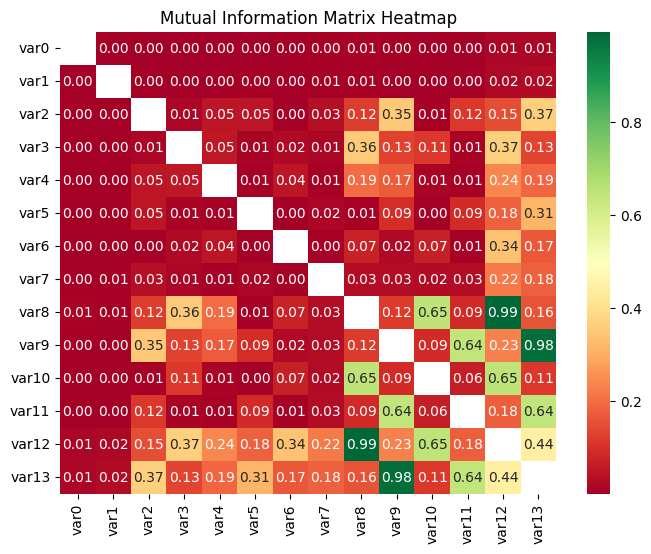

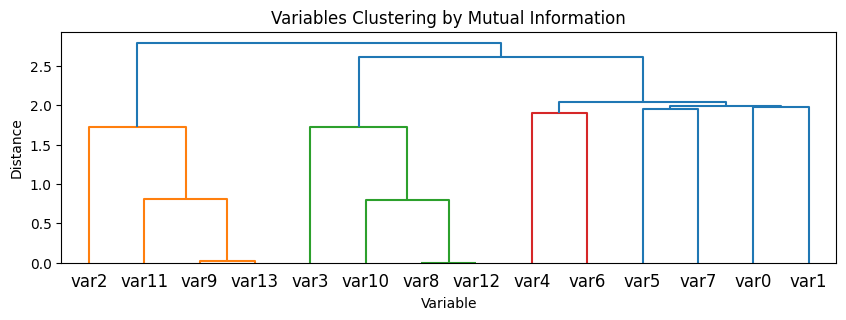

In [ ]:
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
import seaborn as sns

# Fill NaN with zeros or small value and convert to "distance"
mi_dist = mi_matrix.fillna(0).max().max() - mi_matrix.fillna(0)
mi_dist = mi_dist + mi_dist.T  # make symmetric

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(mi_matrix.astype(float), cmap='RdYlGn', annot=True, fmt=".2f")
plt.title("Mutual Information Matrix Heatmap")
plt.show()

# Dendrogram
X = squareform(mi_dist.values, checks=False)
Z = linkage(X, method='ward')

plt.figure(figsize=(10, 3))
dendrogram(Z, labels=cols)
plt.title("Variables Clustering by Mutual Information")
plt.xlabel("Variable")
plt.ylabel("Distance")
plt.show()

In [ ]:
domain_sizes = df.nunique()
obs_ratio_matrix = pd.DataFrame(np.nan, index=cols, columns=cols)
for i in range(n):
    for j in range(n):
        col_i, col_j = cols[i], cols[j]
        observed = df[[col_i, col_j]].drop_duplicates()
        actual_count = len(observed)
        possible_count = domain_sizes[col_i] * domain_sizes[col_j]
        ratio = actual_count / possible_count if possible_count > 0 else np.nan
        obs_ratio_matrix.iloc[i, j] = ratio

display(Markdown("## Ratio of Observed to Possible Value Pairs (Sparsity Matrix)"))
display(
    obs_ratio_matrix.style
        .format("{:.1%}")
        .background_gradient(cmap="Blues", axis=None)
)

## Ratio of Observed to Possible Value Pairs (Sparsity Matrix)

,var0,var1,var2,var3,var4,var5,var6,var7,var8,var9,var10,var11,var12,var13
var0,33.3%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%
var1,100.0%,33.3%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%
var2,100.0%,100.0%,50.0%,100.0%,75.0%,100.0%,100.0%,100.0%,75.0%,62.5%,100.0%,100.0%,87.5%,75.0%
var3,100.0%,100.0%,100.0%,50.0%,75.0%,100.0%,100.0%,100.0%,62.5%,75.0%,100.0%,100.0%,81.2%,87.5%
var4,100.0%,100.0%,75.0%,75.0%,50.0%,100.0%,75.0%,100.0%,62.5%,62.5%,100.0%,100.0%,68.8%,75.0%
var5,100.0%,100.0%,100.0%,100.0%,100.0%,50.0%,100.0%,100.0%,100.0%,87.5%,100.0%,100.0%,87.5%,87.5%
var6,100.0%,100.0%,100.0%,100.0%,75.0%,100.0%,50.0%,100.0%,87.5%,87.5%,100.0%,100.0%,81.2%,81.2%
var7,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,50.0%,87.5%,100.0%,100.0%,100.0%,81.2%,87.5%
var8,100.0%,100.0%,75.0%,62.5%,62.5%,100.0%,87.5%,87.5%,25.0%,50.0%,50.0%,75.0%,25.0%,68.8%
var9,100.0%,100.0%,62.5%,75.0%,62.5%,87.5%,87.5%,100.0%,50.0%,25.0%,75.0%,50.0%,68.8%,25.0%


In [ ]:
entropy_vec = pd.Series(
    [entropy(df[col].value_counts(normalize=True), base=2) for col in cols],
    index=cols
)
display(Markdown("## Univariate Entropy (H) for each variable:"))
display(
    entropy_vec.to_frame("Entropy (bits)").style
        .background_gradient(cmap="PuRd")
        .format("{:.3f}")
)

## Univariate Entropy (H) for each variable:

,Entropy (bits)
var0,1.580
var1,1.578
var2,0.829
var3,0.877
var4,0.586
var5,0.829
var6,0.813
var7,0.624
var8,1.434
var9,1.414


Chow-Liu Bits: 2017.4, Naive Bits: 3623.6, Compression Factor: 0.557


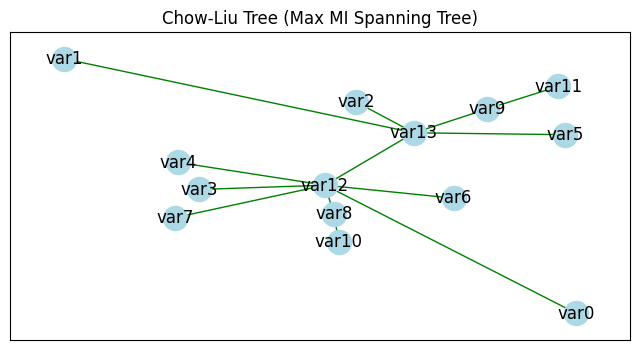

In [ ]:
# 1. MI Matrix
from sklearn.metrics import mutual_info_score
cols = df.columns
n = len(cols)
mi_matrix = pd.DataFrame(np.nan, index=cols, columns=cols)
for i in range(n):
    for j in range(n):
        mi_matrix.iloc[i, j] = mutual_info_score(df.iloc[:, i], df.iloc[:, j])

# 2. Chow-Liu Tree (MST with NetworkX)
import networkx as nx
G = nx.Graph()
for i in range(n):
    for j in range(i+1, n):
        G.add_edge(cols[i], cols[j], weight=mi_matrix.iloc[i, j])
mst = nx.maximum_spanning_tree(G, weight='weight')
root = list(cols)[0]
tree = nx.bfs_tree(mst, root)
parent_map = {child: parent for parent, child in tree.edges()}

# 3. Compute Chow-Liu Model Bits
from scipy.stats import entropy
N = len(df)
def cond_entropy(child, parent):
    vals = []
    for pv in df[parent].unique():
        subset = df[child][df[parent] == pv]
        if len(subset) == 0:
            continue
        pvals = subset.value_counts(normalize=True)
        h = entropy(pvals, base=2)
        vals.append(len(subset) / N * h)
    return sum(vals)
root = list(tree)[0]
total_entropy = entropy(df[root].value_counts(normalize=True), base=2)
for child in cols:
    if child == root:
        continue
    parent = parent_map.get(child, None)
    if parent is not None:
        total_entropy += cond_entropy(child, parent)
total_bits = N * total_entropy

# 4. Compute Naive Encoding Bits (Independent Columns)
marginal_entropy = 0
for col in cols:
    p = df[col].value_counts(normalize=True)
    marginal_entropy += entropy(p, base=2)
uncompressed_bits = N * marginal_entropy

# 5. Report Compression Factor
compression_factor = total_bits / uncompressed_bits
print(f"Chow-Liu Bits: {total_bits:.1f}, Naive Bits: {uncompressed_bits:.1f}, "
      f"Compression Factor: {compression_factor:.3f}")

# 6. Visualize
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
nx.draw_networkx(mst, with_labels=True, node_color='lightblue', edge_color='green')
plt.title("Chow-Liu Tree (Max MI Spanning Tree)")
plt.show()